## **Proyecto 2: guardar datos en la microSD**

La idea será:

- Inicializar la tarjeta microSD.
- Crear un archivo.
- Escribir texto dentro.
- Leerlo nuevamente.
- Ver el resultado en el Monitor Serie

**Esto te enseña algo muy útil:** almacenamiento local, que después podemos reutilizar para guardar lecturas del ADC, datos del sensor cardíaco, registros, configuraciones, etc.

Freenove indica que tu placa usa SDMMC en modo de 1 bit y estos pines están definidos específicamente para la tarjeta:

- CMD → GPIO 38
- CLK → GPIO 39
- D0 → GPIO 40

Freenove incluso avisa en el ejemplo: **“Please do not modify it."**

Ahora hagamos la prueba oficial de lectura/escritura. Creamos un sketch nuevo

```bash
#include "FS.h"
#include "SD_MMC.h"

#define SD_MMC_CMD 38
#define SD_MMC_CLK 39
#define SD_MMC_D0  40

void setup() {
  Serial.begin(115200);
  delay(1000);

  Serial.println("Iniciando tarjeta SD...");

  SD_MMC.setPins(SD_MMC_CLK, SD_MMC_CMD, SD_MMC_D0);

  if (!SD_MMC.begin("/sdcard", true)) {
    Serial.println("ERROR: No se pudo montar la tarjeta SD.");
    return;
  }

  uint8_t cardType = SD_MMC.cardType();

  if (cardType == CARD_NONE) {
    Serial.println("ERROR: No se detecto ninguna tarjeta SD.");
    return;
  }

  Serial.print("Tipo de tarjeta: ");

  if (cardType == CARD_MMC) {
    Serial.println("MMC");
  } else if (cardType == CARD_SD) {
    Serial.println("SDSC");
  } else if (cardType == CARD_SDHC) {
    Serial.println("SDHC");
  } else {
    Serial.println("DESCONOCIDO");
  }

  uint64_t cardSize = SD_MMC.cardSize() / (1024 * 1024);

  Serial.print("Capacidad: ");
  Serial.print(cardSize);
  Serial.println(" MB");

  File archivo = SD_MMC.open("/prueba.txt", FILE_WRITE);

  if (!archivo) {
    Serial.println("ERROR: No se pudo crear prueba.txt");
    return;
  }

  archivo.println("Hola desde mi ESP32-S3 Freenove.");
  archivo.println("Esta linea fue escrita en la tarjeta SD.");
  archivo.close();

  Serial.println("Archivo prueba.txt creado.");

  archivo = SD_MMC.open("/prueba.txt");

  if (!archivo) {
    Serial.println("ERROR: No se pudo abrir prueba.txt.");
    return;
  }

  Serial.println();
  Serial.println("Contenido del archivo:");

  while (archivo.available()) {
    Serial.write(archivo.read());
  }

  archivo.close();

  Serial.println();
  Serial.println("Prueba terminada correctamente.");
}

void loop() {
}
```

Este código hace algo un poco más didáctico que el ejemplo completo de Freenove: inicializa la SD con el mismo método oficial, identifica el tipo de tarjeta, muestra su capacidad, crea prueba.txt, escribe dentro y luego vuelve a leerlo. El ejemplo oficial usa igualmente FS.h, SD_MMC.h, esos tres GPIO y SD_MMC.setPins(...).

### **Ahora**

Con la SD de 1 GB ya insertada y el cable conectado por USB-UART:

1. Pulsa ✓ Verify.
2. Si compila correctamente, pulsa → Upload.
3. Abre el Monitor Serie.
4. Déjalo en 115200 baud.
5. Si no aparece nada tras la carga, pulsa una vez RST en la placa.

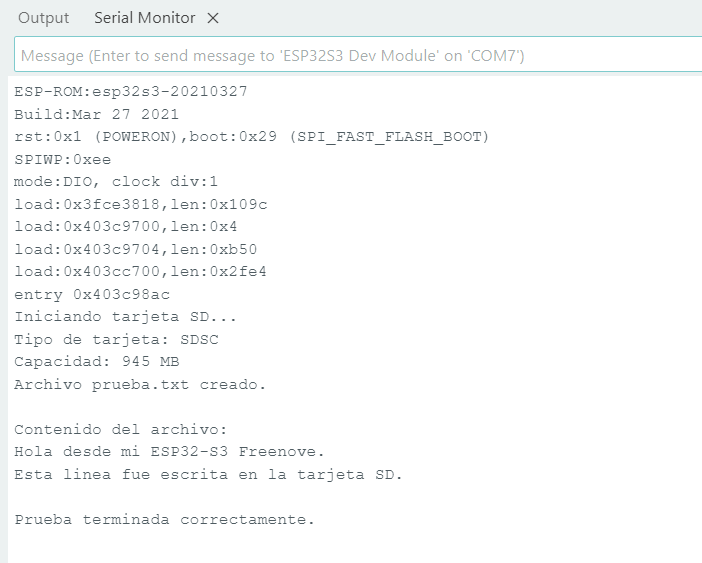

La prueba salió completamente bien.

Tu ESP32-S3 confirmó todo esto:

- Detectó la microSD.
- La identificó como SDSC.
- Reconoció una capacidad de 945 MB, que es coherente con una tarjeta comercial de 1 GB.
- Creó el archivo prueba.txt.
- Escribió correctamente dentro.
- Volvió a abrir el archivo.
- Leyó y mostró el contenido en el Monitor Serie.

Lo importante de esta prueba es que ya comprobamos que el ESP32 puede usar almacenamiento local sin depender de Internet ni de la PC.